# Motion-Activated Security Cam — Google Colab Walkthrough

**Lumexa Computer Vision Track**

A motion detector built from classic computer vision techniques — no machine
learning model required. It uses OpenCV's `cv2.createBackgroundSubtractorMOG2`
to build a statistical model of "the normal, unmoving scene" from a video
stream, then flags regions that differ significantly from that model as
motion, after noise cleanup and area filtering.

This notebook is fully self-contained and works with **Runtime → Run all** —
no webcam, no files to upload, no API keys. Since Colab has no camera device
and no live display window, we **generate a synthetic demo video directly in
the notebook** (a noisy static background with a couple of shapes that hold
still, then move) and run the exact same detection pipeline against it.

**What you'll do:**
1. Read the privacy considerations that apply to any motion-triggered camera system
2. Review the centralized configuration (the same tunables as the original project)
3. Generate a synthetic demo video frame-by-frame with OpenCV drawing functions
4. Port the MOG2 background-subtraction motion detector
5. Run it across every frame, logging motion events with a cooldown between them
6. Visualize representative frames and a full motion timeline
7. (Optional) Upload your own short video and run the same pipeline on it


## Privacy Considerations — Please Read First

Building a motion-triggered camera system carries real responsibility. Before
running this project, or any derivative of it, in any real space:

- **Only monitor spaces you have the clear right to monitor.** Never point a
  system like this at a space (a neighbor's property, a shared area you don't
  control, a public street in many jurisdictions) without confirming you're
  legally and ethically allowed to record it.
- **Tell the people who might be recorded.** If this runs in a shared home,
  classroom, or workplace, let everyone who might appear on camera know it's
  active, what it does (detects motion and saves snapshots/clips), and where
  that footage goes. A visible sign or verbal notice is good practice, not
  just a legal nicety.
- **Think about storage and retention.** A real deployment of this saves
  snapshots and clips to disk with no automatic deletion. Decide and document
  how long you'll keep footage, who can access it, and how you'll securely
  delete it when it's no longer needed. Recorded video of real people is
  sensitive data — treat it that way.
- **This is a learning tool, not a certified security product.** It has no
  professional monitoring, no tamper detection, no encrypted storage, and no
  vetted reliability guarantees. Do not rely on it as your only safeguard for
  anything genuinely safety-critical.
- **Motion detection has known limitations.** Lighting changes, moving
  shadows, pets, and camera vibration can all trigger false positives, and
  very slow or very small movements can be missed entirely. Never treat a
  "no motion detected" result as a guarantee that nothing happened.


In [1]:
# All packages used below are preinstalled in Google Colab.
# The guarded install below is only a safety net for environments where they are not.
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
print("OpenCV version:", cv2.__version__)
print("Libraries loaded.")


OpenCV version: 5.0.0
Libraries loaded.


## Step 1: Configuration

All tunable settings live in one place, exactly as in the original project's
`config.py` — this is a deliberate teaching point: centralizing "knobs" makes
a computer vision pipeline easy to tune without hunting through code.

A few settings from the original are adapted for this notebook:
- `CAMERA_INDEX`, `CAPTURES_DIR`, `RECORD_VIDEO_CLIPS`, `CLIP_*` are dropped —
  there's no webcam and no persistent disk to save captures to in a batch
  Colab run; instead we display results inline with matplotlib.
- `COOLDOWN_SECONDS` becomes `COOLDOWN_FRAMES` — since we're processing a
  batch of synthetic frames rather than a live stream, there's no real
  wall-clock "now" to measure against, so the cooldown is expressed directly
  in frames instead of seconds.


In [2]:
class Config:
    # --- Background subtraction (motion detection) ---
    BACKGROUND_HISTORY = 500     # number of frames used to build the background model
    VAR_THRESHOLD = 40           # sensitivity: lower = more sensitive, more false positives
    DETECT_SHADOWS = True        # exclude cast shadows from motion counting

    # --- Motion filtering ---
    MIN_MOTION_AREA = 800        # minimum contour area (pixels) to count as real motion
    DILATE_ITERATIONS = 2        # morphological cleanup of the foreground mask

    # --- Event handling ---
    COOLDOWN_FRAMES = 45         # minimum frames between separate logged motion events

    # --- Display ---
    BOX_COLOR = (0, 0, 255)      # BGR red for motion boxes
    FRAME_WIDTH = 640
    FRAME_HEIGHT = 480

config = Config()
print("Configuration loaded:")
for key, value in vars(Config).items():
    if not key.startswith("_"):
        print(f"  {key} = {value}")


Configuration loaded:
  BACKGROUND_HISTORY = 500
  VAR_THRESHOLD = 40
  DETECT_SHADOWS = True
  MIN_MOTION_AREA = 800
  DILATE_ITERATIONS = 2
  COOLDOWN_FRAMES = 45
  BOX_COLOR = (0, 0, 255)
  FRAME_WIDTH = 640
  FRAME_HEIGHT = 480


## Step 2: Generate a synthetic demo video

Instead of a live webcam, we build a short demo video entirely in code:

- A **noisy static background** (random per-pixel sensor-like noise on a flat
  gray canvas) for every frame, so the background subtractor has something
  realistic to model — real camera sensors are never perfectly static.
- The **first 40 frames hold still** (no moving object) so MOG2 can learn
  "the normal, unmoving scene" before anything happens.
- Then a **filled circle sweeps diagonally across the frame** (frames 40-99):
  our first motion event.
- The scene **goes quiet again** (frames 100-149) so the background model can
  settle back down.
- Then a **filled rectangle sweeps across the frame from the opposite
  direction** (frames 150-219): our second motion event.

This gives us a deterministic, reproducible video with clearly-defined
"nothing happening" and "something happening" periods, with zero network
dependency or licensing concerns.


In [3]:
RNG = np.random.default_rng(42)

FRAME_W, FRAME_H = Config.FRAME_WIDTH, Config.FRAME_HEIGHT
NUM_QUIET_START = 40     # frames to let MOG2 learn the background
NUM_BURST_1 = 60         # frames the circle moves for
NUM_QUIET_MID = 50       # quiet frames between the two motion bursts
NUM_BURST_2 = 70         # frames the rectangle moves for
TOTAL_FRAMES = NUM_QUIET_START + NUM_BURST_1 + NUM_QUIET_MID + NUM_BURST_2

BACKGROUND_GRAY = 60
NOISE_STD = 6.0


def make_background(rng):
    # A flat gray canvas plus per-frame Gaussian sensor noise.
    base = np.full((FRAME_H, FRAME_W, 3), BACKGROUND_GRAY, dtype=np.float32)
    noise = rng.normal(0.0, NOISE_STD, size=base.shape)
    frame = np.clip(base + noise, 0, 255).astype(np.uint8)
    # A static decorative rectangle (e.g. a doorway outline) that never moves,
    # so the "normal scene" isn't perfectly blank.
    cv2.rectangle(frame, (20, 20), (FRAME_W - 20, FRAME_H - 20), (90, 90, 90), 2)
    return frame


def lerp(a, b, t):
    return a + (b - a) * t


frames = []

# Phase A: quiet, nothing moving.
for i in range(NUM_QUIET_START):
    frames.append(make_background(RNG))

# Phase B: a filled circle sweeps from bottom-left to top-right.
circle_start, circle_end = (80, 380), (560, 120)
for i in range(NUM_BURST_1):
    frame = make_background(RNG)
    t = i / (NUM_BURST_1 - 1)
    cx = int(lerp(circle_start[0], circle_end[0], t))
    cy = int(lerp(circle_start[1], circle_end[1], t))
    cv2.circle(frame, (cx, cy), 30, (40, 200, 40), -1)
    frames.append(frame)

# Phase C: quiet again, letting the background model settle.
for i in range(NUM_QUIET_MID):
    frames.append(make_background(RNG))

# Phase D: a filled rectangle sweeps from top-right to bottom-left.
rect_start, rect_end = (560, 70), (50, 380)
rect_w, rect_h = 90, 60
for i in range(NUM_BURST_2):
    frame = make_background(RNG)
    t = i / (NUM_BURST_2 - 1)
    rx = int(lerp(rect_start[0], rect_end[0], t))
    ry = int(lerp(rect_start[1], rect_end[1], t))
    cv2.rectangle(frame, (rx, ry), (rx + rect_w, ry + rect_h), (40, 40, 220), -1)
    frames.append(frame)

print(f"Generated {len(frames)} synthetic frames ({FRAME_W}x{FRAME_H}).")
print(f"  Phase A (quiet):        frames 0-{NUM_QUIET_START - 1}")
print(f"  Phase B (circle moves): frames {NUM_QUIET_START}-{NUM_QUIET_START + NUM_BURST_1 - 1}")
print(f"  Phase C (quiet):        frames {NUM_QUIET_START + NUM_BURST_1}-{NUM_QUIET_START + NUM_BURST_1 + NUM_QUIET_MID - 1}")
print(f"  Phase D (rect moves):   frames {NUM_QUIET_START + NUM_BURST_1 + NUM_QUIET_MID}-{TOTAL_FRAMES - 1}")


Generated 220 synthetic frames (640x480).
  Phase A (quiet):        frames 0-39
  Phase B (circle moves): frames 40-99
  Phase C (quiet):        frames 100-149
  Phase D (rect moves):   frames 150-219


## Step 3: The motion detector (MOG2 background subtraction)

This is a direct port of the original project's `motion_detector.py`, using
the same pipeline and the same parameters:

1. **Background modeling**: `cv2.createBackgroundSubtractorMOG2` builds and
   continuously updates a statistical model of the "normal" (unmoving) scene
   from recent frames.
2. **Foreground mask**: `subtractor.apply(frame)` returns a grayscale mask —
   bright where a pixel differs significantly from the background model, dark
   where it matches it. Shadow pixels are marked as an intermediate gray
   value (127) when `detectShadows=True`.
3. **Shadow-aware thresholding**: thresholding the mask at 200 keeps only
   strong foreground (255) and excludes shadows (127) — this is what makes
   the detector shadow-aware rather than shadow-triggered.
4. **Morphological cleanup**: `cv2.dilate` / `cv2.erode` remove small,
   isolated noise pixels and fill small gaps within real moving regions.
5. **Contour detection + area filtering**: `cv2.findContours` finds outlines
   of connected bright regions; only contours with area ≥ `MIN_MOTION_AREA`
   are treated as genuine motion (this is what filters out sensor noise and
   tiny flickers).


In [4]:
class MotionDetector:
    def __init__(self, config):
        self.config = config
        self.subtractor = cv2.createBackgroundSubtractorMOG2(
            history=config.BACKGROUND_HISTORY,
            varThreshold=config.VAR_THRESHOLD,
            detectShadows=config.DETECT_SHADOWS,
        )
        self._kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    def detect(self, frame_bgr):
        # Runs motion detection on a single BGR frame. Returns
        # (motion_boxes, total_motion_area):
        #   - motion_boxes: list of (x, y, w, h) bounding boxes, one per
        #     detected motion region with contour area >= MIN_MOTION_AREA.
        #   - total_motion_area: sum of the qualifying contour areas (pixels),
        #     used later to plot a motion timeline.
        #
        # Slight blur reduces sensor-noise-driven false positives.
        blurred = cv2.GaussianBlur(frame_bgr, (5, 5), 0)

        fg_mask = self.subtractor.apply(blurred)

        # MOG2 marks shadow pixels as gray (127) when detectShadows=True.
        # Threshold at 200 keeps only strong foreground (255), excluding shadows.
        _, thresholded = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

        # Morphological cleanup: remove small noise, fill small gaps in real regions.
        cleaned = cv2.dilate(thresholded, self._kernel, iterations=self.config.DILATE_ITERATIONS)
        cleaned = cv2.erode(cleaned, self._kernel, iterations=1)

        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        motion_boxes = []
        total_motion_area = 0.0
        for contour in contours:
            area = cv2.contourArea(contour)
            if area >= self.config.MIN_MOTION_AREA:
                x, y, w, h = cv2.boundingRect(contour)
                motion_boxes.append((x, y, w, h))
                total_motion_area += area

        return motion_boxes, total_motion_area


def draw_overlay(frame, motion_boxes, config):
    # Draws bounding boxes plus the same on-screen indicators as the
    # original live app (adapted: no FPS counter or REC dot, since there's
    # no real-time loop or clip recording here).
    annotated = frame.copy()
    for (x, y, w, h) in motion_boxes:
        cv2.rectangle(annotated, (x, y), (x + w, y + h), config.BOX_COLOR, 2)

    cv2.putText(annotated, "MONITORING ACTIVE", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2, cv2.LINE_AA)

    if motion_boxes:
        cv2.putText(annotated, "MOTION DETECTED", (10, 55),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)

    return annotated


print("MotionDetector defined.")


MotionDetector defined.


## Step 4: Process every frame

We replace the original's live `while True: ... cv2.imshow(...) ... waitKey('q')`
loop (which needs a real display window and a camera) with a straightforward
batch loop: process every synthetic frame in order, exactly as the original
processed every live frame in order.

The event-handling logic is preserved: motion boxes are only turned into a
**logged event** (console line + saved representative frame) when there's
qualifying motion *and* the cooldown period has elapsed since the last
logged event — this avoids spamming a log entry on every single frame during
one continuous motion episode, same as the original's `COOLDOWN_SECONDS`
check, just measured in frames instead of wall-clock time.


In [5]:
detector = MotionDetector(config)

motion_area_per_frame = []
events = []              # each: {"frame": idx, "count": n, "boxes": [...], "annotated": frame}
last_event_frame = -config.COOLDOWN_FRAMES  # allow an event right away if motion appears immediately

for idx, frame in enumerate(frames):
    motion_boxes, total_area = detector.detect(frame)
    motion_area_per_frame.append(total_area)

    if motion_boxes and (idx - last_event_frame) >= config.COOLDOWN_FRAMES:
        last_event_frame = idx
        annotated = draw_overlay(frame, motion_boxes, config)
        events.append({"frame": idx, "count": len(motion_boxes), "boxes": motion_boxes, "annotated": annotated})
        print(f"[frame {idx:04d}] MOTION DETECTED -- {len(motion_boxes)} region(s) flagged "
              f"(total area={total_area:.0f}px).")

motion_area_per_frame = np.array(motion_area_per_frame)

print()
print(f"Processed {len(frames)} frames. Logged {len(events)} motion event(s) "
      f"(cooldown = {config.COOLDOWN_FRAMES} frames).")


[frame 0040] MOTION DETECTED -- 1 region(s) flagged (total area=3338px).


[frame 0085] MOTION DETECTED -- 1 region(s) flagged (total area=3340px).


[frame 0150] MOTION DETECTED -- 1 region(s) flagged (total area=5406px).


[frame 0195] MOTION DETECTED -- 1 region(s) flagged (total area=6324px).

Processed 220 frames. Logged 4 motion event(s) (cooldown = 45 frames).


## Step 5: Sanity check

Before trusting the visualizations below, let's confirm the pipeline actually
did what it was supposed to: no motion logged during the quiet phases, and at
least one motion event logged during each of the two moving-object phases.


In [6]:
quiet_a_end = NUM_QUIET_START
burst_1_end = NUM_QUIET_START + NUM_BURST_1
quiet_mid_end = burst_1_end + NUM_QUIET_MID

events_in_quiet_a = [e for e in events if e["frame"] < quiet_a_end]
events_in_burst_1 = [e for e in events if quiet_a_end <= e["frame"] < burst_1_end]
events_in_burst_2 = [e for e in events if e["frame"] >= quiet_mid_end]

assert len(events) > 0, "Expected at least one motion event, got none -- tune MIN_MOTION_AREA/object size."
assert len(events_in_quiet_a) == 0, f"False positive(s) during the quiet startup phase: {events_in_quiet_a}"
assert len(events_in_burst_1) > 0, "The moving circle (phase B) never triggered a motion event."
assert len(events_in_burst_2) > 0, "The moving rectangle (phase D) never triggered a motion event."

print("Sanity checks passed:")
print(f"  Quiet startup phase (0-{quiet_a_end - 1}): {len(events_in_quiet_a)} event(s) -- expected 0")
print(f"  Circle motion phase ({quiet_a_end}-{burst_1_end - 1}): {len(events_in_burst_1)} event(s) -- expected > 0")
print(f"  Rectangle motion phase ({quiet_mid_end}-{TOTAL_FRAMES - 1}): {len(events_in_burst_2)} event(s) -- expected > 0")


Sanity checks passed:
  Quiet startup phase (0-39): 0 event(s) -- expected 0
  Circle motion phase (40-99): 2 event(s) -- expected > 0
  Rectangle motion phase (150-219): 2 event(s) -- expected > 0


## Step 6: Visualize representative frames

A handful of frames, shown side by side: one calm frame with no motion
detected, followed by the frame from each logged event with its bounding
box(es) drawn in red.


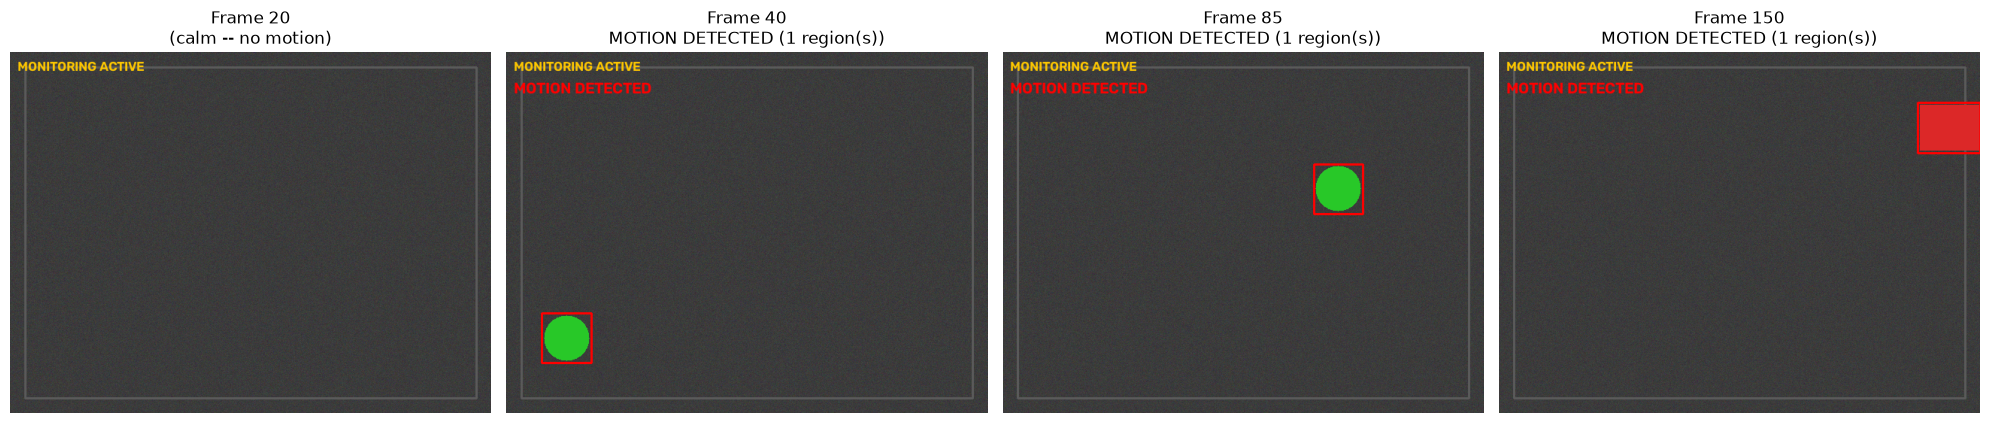

In [7]:
calm_frame_idx = NUM_QUIET_START // 2  # well within the quiet startup phase
calm_boxes, _ = detector.detect(frames[calm_frame_idx].copy())  # note: this call also feeds the
                                                                  # subtractor, so we display a fresh
                                                                  # already-processed quiet frame instead
calm_display = draw_overlay(frames[calm_frame_idx], [], config)

# Show the calm frame plus up to 3 representative motion events.
display_events = events[:3]
num_panels = 1 + len(display_events)

fig, axes = plt.subplots(1, num_panels, figsize=(5 * num_panels, 4.2))
if num_panels == 1:
    axes = [axes]

axes[0].imshow(cv2.cvtColor(calm_display, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Frame {calm_frame_idx}\n(calm -- no motion)")
axes[0].axis("off")

for ax, event in zip(axes[1:], display_events):
    ax.imshow(cv2.cvtColor(event["annotated"], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {event['frame']}\nMOTION DETECTED ({event['count']} region(s))")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Step 7: Motion timeline

The full picture: total detected motion area per frame across the whole
video, with the `MIN_MOTION_AREA` event threshold marked and each logged
event flagged. Note how the timeline sits near zero during the quiet phases
and rises well above the threshold during each moving-object phase.


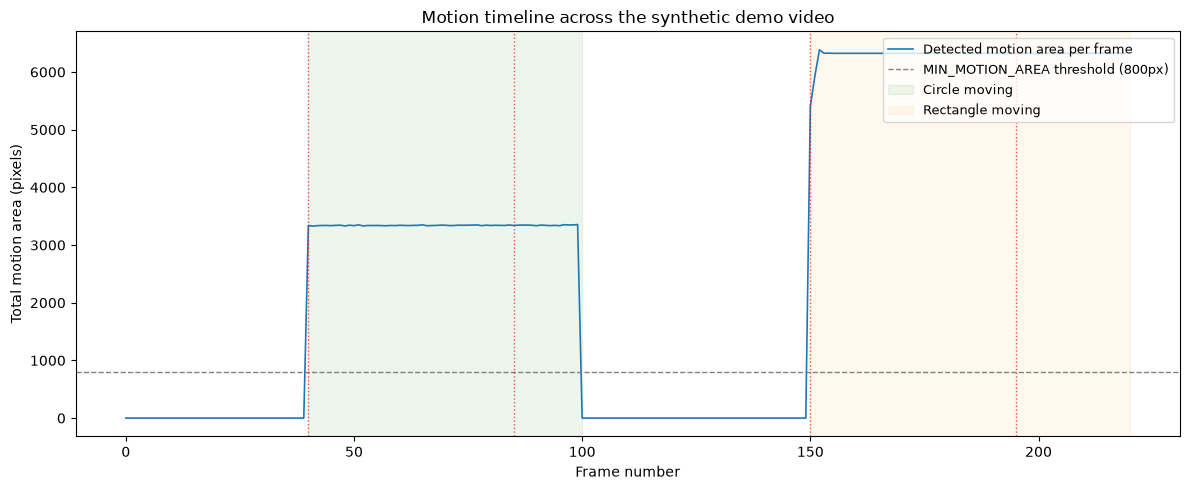

4 motion event(s) logged, marked as red dotted lines above.


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(motion_area_per_frame, color="#1f77b4", linewidth=1.2, label="Detected motion area per frame")
ax.axhline(config.MIN_MOTION_AREA, color="gray", linestyle="--", linewidth=1,
           label=f"MIN_MOTION_AREA threshold ({config.MIN_MOTION_AREA}px)")

for event in events:
    ax.axvline(event["frame"], color="red", linestyle=":", linewidth=1, alpha=0.7)

# Shade the two "something is moving" phases for context.
ax.axvspan(NUM_QUIET_START, NUM_QUIET_START + NUM_BURST_1, color="green", alpha=0.07, label="Circle moving")
ax.axvspan(quiet_mid_end, TOTAL_FRAMES, color="orange", alpha=0.07, label="Rectangle moving")

ax.set_xlabel("Frame number")
ax.set_ylabel("Total motion area (pixels)")
ax.set_title("Motion timeline across the synthetic demo video")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"{len(events)} motion event(s) logged, marked as red dotted lines above.")


## Common Problems (from the original project)

- **False positives from lighting changes**: gradual daylight changes, a
  light turning on/off, or reflections can all register as "motion." Try
  increasing `VAR_THRESHOLD`, or ensure `DETECT_SHADOWS = True` is active
  (it is, by default) so cast shadows are excluded.
- **False positives from small movements** (a curtain flutter, a pet): raise
  `MIN_MOTION_AREA` to require larger moving regions before counting as
  motion.
- **Missed slow or very small motion**: background subtraction is tuned for
  typical human-scale movement; very slow drifting motion can sometimes be
  absorbed into the background model over time. Lower `BACKGROUND_HISTORY`
  slightly if this is a problem in your setting.
- **Disk filling up over time** (in a real, non-Colab deployment): this
  project does not automatically delete old captures. Periodically review
  and clean out the captures folder, or add a retention-policy script.

## Extensions

- Add a retention policy: automatically delete captures older than N days on startup.
- Add region-of-interest masking, so motion is only monitored within a
  specific part of the frame (e.g., ignoring a window where outdoor tree
  movement causes false positives).
- **Optional notification integration (not implemented here, by design)**:
  you could extend this to send an email or push notification when motion is
  detected, using a service like SMTP (Python's built-in `smtplib`) or a
  third-party push notification API. This project intentionally does not
  implement any external notification service — it only logs to the console
  and displays results inline — so it has zero external dependencies, no
  required accounts, and no risk of accidentally sharing footage with a
  third-party service without explicit, deliberate setup by whoever deploys
  it.
- Combine with the Object Recognition project: run object detection only on
  frames where motion was already detected, to additionally report *what*
  triggered the motion (e.g., "person" vs. "cat") — this two-stage approach
  also saves significant compute compared to running object detection on
  every single frame continuously.


## Optional — try it yourself

This section is **optional and manual** — it's skipped automatically outside
of Google Colab (for example, during automated testing of this notebook) and
is not required for the rest of the notebook to work.

If you're running this in Google Colab, you can upload your own short video
file (a phone recording works well — ideally a few seconds of a still scene
followed by something moving through it) and run the exact same
`MotionDetector` pipeline on it.


In [9]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print("Not running in Google Colab -- skipping the upload step.")
    print("Open this notebook in Google Colab and re-run this cell to try your own video.")
else:
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
    else:
        video_path = next(iter(uploaded))
        cap = cv2.VideoCapture(video_path)

        your_detector = MotionDetector(config)
        your_motion_area = []
        your_events = []
        your_last_event_frame = -config.COOLDOWN_FRAMES
        idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            boxes, total_area = your_detector.detect(frame)
            your_motion_area.append(total_area)
            if boxes and (idx - your_last_event_frame) >= config.COOLDOWN_FRAMES:
                your_last_event_frame = idx
                your_events.append({"frame": idx, "count": len(boxes), "boxes": boxes,
                                     "annotated": draw_overlay(frame, boxes, config)})
                print(f"[frame {idx:04d}] MOTION DETECTED -- {len(boxes)} region(s) flagged.")
            idx += 1

        cap.release()
        print(f"\nProcessed {idx} frames from '{video_path}'. Logged {len(your_events)} motion event(s).")

        if your_events:
            fig, axes = plt.subplots(1, min(3, len(your_events)), figsize=(5 * min(3, len(your_events)), 4.2))
            if min(3, len(your_events)) == 1:
                axes = [axes]
            for ax, event in zip(axes, your_events[:3]):
                ax.imshow(cv2.cvtColor(event["annotated"], cv2.COLOR_BGR2RGB))
                ax.set_title(f"Frame {event['frame']} -- {event['count']} region(s)")
                ax.axis("off")
            plt.tight_layout()
            plt.show()


Not running in Google Colab -- skipping the upload step.
Open this notebook in Google Colab and re-run this cell to try your own video.
